In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Year_project/')

Mounted at /content/drive


#### Импорт необходимых библиотек

In [12]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.metrics import cohen_kappa_score, accuracy_score, roc_auc_score
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from glob import glob
from ml.ml_experiments import build_exp_dataframe
from ml.env import DATA_ROOT
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler
import seaborn as sns
import matplotlib.pyplot as plt
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### Загрузка датасета (после ресайза и улучшения качества)

In [ ]:
df_images = build_exp_dataframe(DATA_ROOT, return_images=True)
print(f"Загружено {len(df_images)} изображений.")

Загрузка анатомий из train:   0%|          | 0/7 [00:00<?, ?it/s]

Загрузка XR_WRIST


Исследования..:   0%|          | 0/2349 [00:00<?, ?it/s]

Загрузка XR_FINGER


Исследования..:   0%|          | 0/1865 [00:00<?, ?it/s]

...

Загрузка XR_HUMERUS


Исследования..:   0%|          | 0/132 [00:00<?, ?it/s]

Загрузка XR_ELBOW


Исследования..:   0%|          | 0/152 [00:00<?, ?it/s]

Загружено 37108 изображений.


In [ ]:
df_images["unique_study_id"] = (
    df_images["patient_id"] + "_" + df_images["study_id"]
)

#### Сохранение/загрузка готового DF

In [ ]:
# df_images.to_csv("df_images.csv", index=False)

# df_images = pd.read_csv("df_images.csv")

#### Выделение train/val

In [5]:
train_df = df_images[df_images["split"] == "train"].reset_index(drop=True)
val_df   = df_images[df_images["split"] == "valid"].reset_index(drop=True)

### Необходимые функции

Сбор DF

In [6]:
class MURADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return (
          img,
          float(row["label"]),
          row["unique_study_id"],   # ← вместо старого
          row["anatomy"]
            )

Подсчет метрик

In [7]:
def compute_metrics(df, threshold=0.5):
    y_true = df["label"].values
    y_prob = df["prob"].values
    y_pred = (y_prob > threshold).astype(int)

    return {
        "acc": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "kappa": cohen_kappa_score(y_true, y_pred)
    }

Функция одной эпохи обучения

In [8]:
def train_one_epoch():
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc="Train", leave=False)

    for images, labels, _, _ in loop:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    return total_loss / len(train_loader)

Функция валидации

In [9]:
def validate():
    model.eval()

    all_probs = []
    all_labels = []
    all_study_ids = []
    all_anatomy = []

    loop = tqdm(val_loader, desc="Val", leave=False)

    with torch.no_grad():
        for images, labels, study_ids, anatomy in loop:
            images = images.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_study_ids.extend(study_ids)
            all_anatomy.extend(anatomy)

    return all_probs, all_labels, all_study_ids, all_anatomy

Аггрегация изображений по исследованиям

In [10]:
def aggregate(probs, labels, study_ids, anatomy):
    df = pd.DataFrame({
        "study_id": study_ids,
        "anatomy": anatomy,
        "prob": [p[0] for p in probs],
        "label": labels
    })

    return df.groupby("study_id").agg({
        "prob": "mean",
        "label": "first",
        "anatomy": "first"
    }).reset_index()

Фиксирование SEED

In [11]:
def worker_init_fn(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

Определение лучшего threshold

In [85]:
def threshold(study_df):
  y_true = study_df["label"].values
  y_prob = study_df["prob"].values

  best_t = 0
  best_kappa = -1

  for t in np.linspace(0, 1, 200):
      y_pred = (y_prob > t).astype(int)
      k = cohen_kappa_score(y_true, y_pred)

      if k > best_kappa:
          best_kappa = k
          best_t = t
  return best_t, best_kappa

### Baseline
Архитектура DenseNet121 с одним размороженным блоком

In [ ]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

In [ ]:
train_dataset = MURADataset(train_df, train_transform)
val_dataset   = MURADataset(val_df, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    worker_init_fn=worker_init_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    worker_init_fn=worker_init_fn
)

Определение модели и заморозка всех блоков, кроме последнего.

In [ ]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# 1. freeze everything
for p in model.parameters():
    p.requires_grad = False

# 2. unfreeze last block
for name, p in model.named_parameters():
    if "denseblock4" in name:
        p.requires_grad = True

# 3. classifier
model.classifier = nn.Linear(model.classifier.in_features, 1)

for p in model.classifier.parameters():
    p.requires_grad = True

In [22]:
device = torch.device("cuda")

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

Обучение

In [ ]:
num_epochs = 20
best_kappa = -1
patience = 3
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_loss = train_one_epoch()

    all_probs, all_labels, all_study_ids, all_anatomy = validate()
    study_df = aggregate(all_probs, all_labels, all_study_ids, all_anatomy)

    metrics = compute_metrics(study_df)
    print(epoch, train_loss, metrics)
    if metrics["kappa"] > best_kappa:
        best_kappa = metrics["kappa"]
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        break


Epoch 1/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

0 0.6125227021031607 {'acc': 0.7120743034055728, 'auc': np.float64(0.8035917390002992), 'kappa': np.float64(0.40666308200463075)}

Epoch 2/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

...

Val:   0%|          | 0/48 [00:00<?, ?it/s]

8 0.39127274224642034 {'acc': 0.8090815273477813, 'auc': np.float64(0.878415358960106), 'kappa': np.float64(0.6113993006856575)}

Epoch 10/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

9 0.3726696124617136 {'acc': 0.8132094943240454, 'auc': np.float64(0.8817419934151451), 'kappa': np.float64(0.6200930115690448)}


Лучший threshold

In [ ]:
best_t, best_kappa = threshold(study_df)

print("best threshold:", best_t)
print("best kappa:", best_kappa)

best threshold: 0.47738693467336685
best kappa: 0.6354843173032853


Метрики по всему датасету и по каждой анатомии отдельно

In [ ]:
metrics = compute_metrics(study_df, threshold=best_t)
print(metrics)

by_anatomy = {}

for a in study_df["anatomy"].unique():
    part = study_df[study_df["anatomy"] == a]

    if part["label"].nunique() < 2:
        continue

    by_anatomy[a] = compute_metrics(part, threshold=best_t)

{'acc': 0.8204334365325078, 'auc': np.float64(0.8817419934151451), 'kappa': np.float64(0.6354843173032853)}


In [ ]:
pd.DataFrame(by_anatomy).T

,acc,auc,kappa
XR_WRIST,0.869565,0.911224,0.726462
XR_SHOULDER,0.839506,0.899497,0.678031
XR_FOREARM,0.805825,0.904151,0.613943
XR_HAND,0.803030,0.849953,0.562691
XR_FINGER,0.763636,0.831175,0.523227
XR_HUMERUS,0.858407,0.906583,0.716881
XR_ELBOW,0.790909,0.888558,0.579595


In [ ]:
kappa_scores = {}

In [94]:
kappa_scores['baseline'] = {
    k: float(v['kappa']) for k, v in by_anatomy.items()
}

kappa_scores['baseline']['total'] = float(
    np.mean([v['kappa'] for v in by_anatomy.values()])
    )

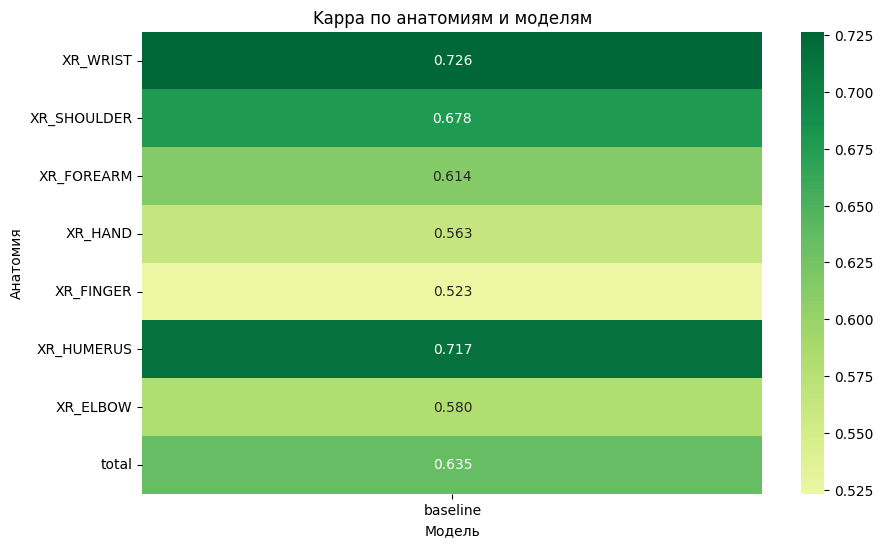

In [95]:
df = pd.DataFrame(kappa_scores)
plt.figure(figsize=(10,6))
sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center = 0.5)

plt.title('Kappa по анатомиям и моделям')
plt.xlabel('Модель')
plt.ylabel('Анатомия')

plt.show()

Сохранение модели

In [ ]:
torch.save(model.state_dict(), "base_DenseNet.pth")

Уже на этапе бейзлайна DenseNet заметно превзошла все эксперименты с ML моделями.

#### Учитываем дисбаланс с помощью увеличения вклада положительного класса

In [ ]:
pos = (study_df["label"] == 1).sum()
neg = (study_df["label"] == 0).sum()
pos_weight = neg/pos
print(pos_weight)

1.1296703296703297


In [ ]:
pos_weight_tensor = torch.tensor([pos_weight]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# 1. freeze everything
for p in model.parameters():
    p.requires_grad = False

# 2. unfreeze last block
for name, p in model.named_parameters():
    if "denseblock4" in name:
        p.requires_grad = True

# 3. classifier
model.classifier = nn.Linear(model.classifier.in_features, 1)

for p in model.classifier.parameters():
    p.requires_grad = True

In [ ]:
model = model.to(device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

In [ ]:
num_epochs = 20
best_kappa = -1
patience = 5
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_loss = train_one_epoch()

    all_probs, all_labels, all_study_ids, all_anatomy = validate()
    study_df = aggregate(all_probs, all_labels, all_study_ids, all_anatomy)

    metrics = compute_metrics(study_df)
    print(epoch, train_loss, metrics)
    if metrics["kappa"] > best_kappa:
        best_kappa = metrics["kappa"]
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        break


Epoch 1/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

0 0.6494006668314827 {'acc': 0.7389060887512899, 'auc': np.float64(0.8057382306409544), 'kappa': np.float64(0.46665230813410863)}

Epoch 2/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

...

Val:   0%|          | 0/48 [00:00<?, ?it/s]

11 0.34891199542751494 {'acc': 0.803921568627451, 'auc': np.float64(0.8732928550049173), 'kappa': np.float64(0.6003343029566275)}

Epoch 13/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

12 0.3224589153607177 {'acc': 0.8080495356037152, 'auc': np.float64(0.8728096805917818), 'kappa': np.float64(0.6117320120637657)}


In [ ]:
best_t, best_kappa = threshold(study_df)

print("best threshold:", best_t)
print("best kappa:", best_kappa)

best threshold: 0.40703517587939697
best kappa: 0.6232423402137177


In [ ]:
weighted_metrics = compute_metrics(study_df, threshold=best_t)
print(weighted_metrics)

weighted_by_anatomy = {}

for a in study_df["anatomy"].unique():
    part = study_df[study_df["anatomy"] == a]

    if part["label"].nunique() < 2:
        continue

    weighted_by_anatomy[a] = compute_metrics(part, threshold=best_t)

{'acc': 0.8121775025799793, 'auc': np.float64(0.8728096805917818), 'kappa': np.float64(0.6232423402137177)}


In [ ]:
pd.DataFrame(weighted_by_anatomy).T

,acc,auc,kappa
XR_WRIST,0.847826,0.909289,0.691571
XR_SHOULDER,0.796296,0.878298,0.594201
XR_FOREARM,0.854369,0.899623,0.709313
XR_HAND,0.803030,0.836895,0.580645
XR_FINGER,0.751515,0.809832,0.502391
XR_HUMERUS,0.814159,0.889342,0.627531
XR_ELBOW,0.836364,0.912368,0.672185


In [ ]:
kappa_scores['weighted'] = {
    k: float(v['kappa']) for k, v in weighted_by_anatomy.items()
}

kappa_scores['weighted']['total'] = float(
    np.mean([v['kappa'] for v in weighted_by_anatomy.values()])
    )

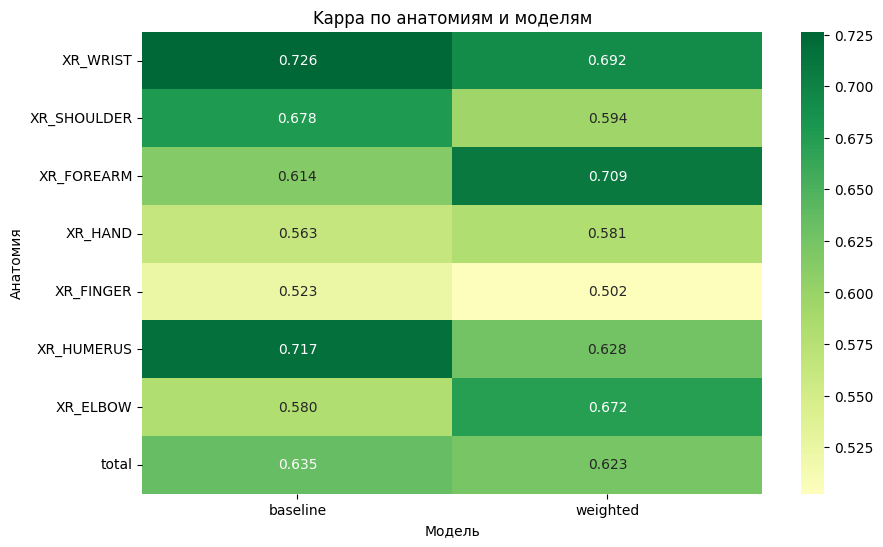

In [93]:
df = pd.DataFrame(kappa_scores)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center = 0.5)

plt.title('Kappa по анатомиям и моделям')
plt.xlabel('Модель')
plt.ylabel('Анатомия')

plt.show()

In [ ]:
torch.save(model.state_dict(), "weighted_DenseNet.pth")

Улучшение заметно в анатомиях XR_FOREARM, XR_HAND и XR_ELBOW. Из графиков этапа EDA видно, что у этих анатомий был заметный дисбаланс классов, однако не все анатомии с дисбалансом показали улучшение метрик на данном этапе.


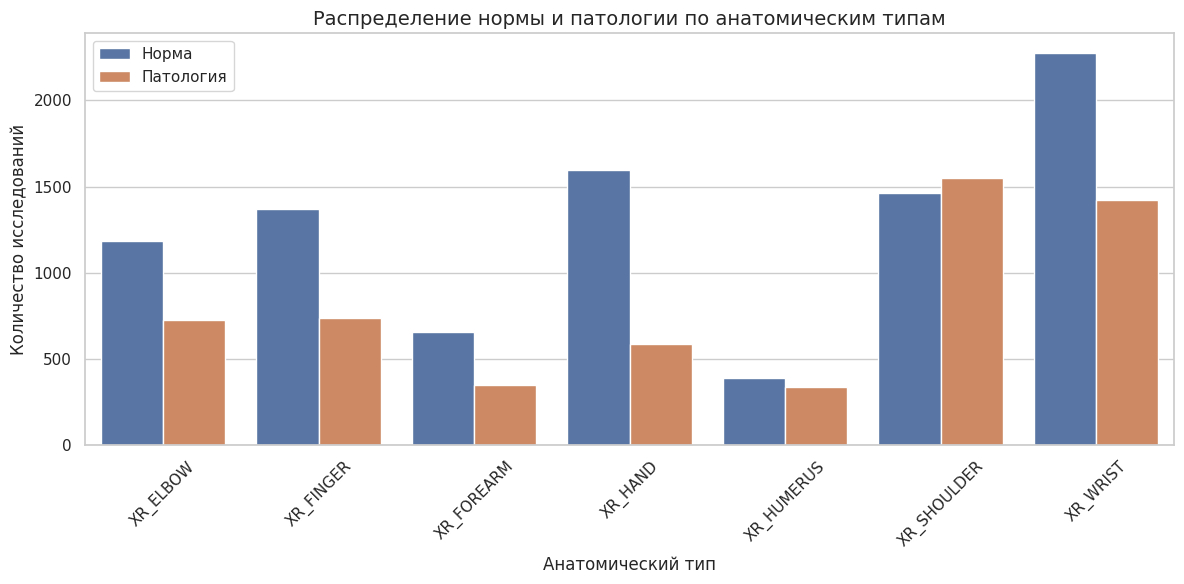

Эксперимент с разморозкой двух последних блоков

In [ ]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# 1. freeze everything
for p in model.parameters():
    p.requires_grad = False

# 2. unfreeze 3 + 4
for name, p in model.named_parameters():
    if name.startswith("features.denseblock4") or name.startswith("features.denseblock3"):
        p.requires_grad = True

# 3. classifier
model.classifier = nn.Linear(model.classifier.in_features, 1)

for p in model.classifier.parameters():
    p.requires_grad = True

In [ ]:
model = model.to(device)

optimizer = torch.optim.Adam([
    {'params': filter(lambda p: p.requires_grad, model.features.parameters()), 'lr': 1e-6},
    {'params': model.classifier.parameters(), 'lr': 1e-5},
])

In [ ]:
num_epochs = 20
best_kappa = -1
patience = 5
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_loss = train_one_epoch()

    all_probs, all_labels, all_study_ids, all_anatomy = validate()
    study_df = aggregate(all_probs, all_labels, all_study_ids, all_anatomy)

    metrics = compute_metrics(study_df)
    print(epoch, train_loss, metrics)
    if metrics["kappa"] > best_kappa:
        best_kappa = metrics["kappa"]
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        break


Epoch 1/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

0 0.7106041902051339 {'acc': 0.6099071207430341, 'auc': np.float64(0.6653183392483004), 'kappa': np.float64(0.19225425724757528)}

Epoch 2/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

...

Val:   0%|          | 0/48 [00:00<?, ?it/s]

18 0.45349056312905905 {'acc': 0.8090815273477813, 'auc': np.float64(0.8748663787574293), 'kappa': np.float64(0.6128846265971897)}

Epoch 20/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

19 0.44791074527155283 {'acc': 0.8163054695562435, 'auc': np.float64(0.8755890024372515), 'kappa': np.float64(0.6269142916471993)}


In [ ]:
best_t, best_kappa = threshold(study_df)

print("best threshold:", best_t)
print("best kappa:", best_kappa)

best threshold: 0.48743718592964824
best kappa: 0.6315764459864075


In [ ]:
blocks2_metrics = compute_metrics(study_df, threshold=best_t)
print(blocks2_metrics)

blocks2_by_anatomy = {}

for a in study_df["anatomy"].unique():
    part = study_df[study_df["anatomy"] == a]

    if part["label"].nunique() < 2:
        continue

    blocks2_by_anatomy[a] = compute_metrics(part, threshold=best_t)

{'acc': 0.8183694530443757, 'auc': np.float64(0.8755890024372515), 'kappa': np.float64(0.6315764459864075)}


In [ ]:
pd.DataFrame(blocks2_by_anatomy).T

,acc,auc,kappa
XR_WRIST,0.880435,0.922230,0.750984
XR_SHOULDER,0.783951,0.877840,0.566977
XR_FOREARM,0.825243,0.900755,0.652939
XR_HAND,0.795455,0.844492,0.547256
XR_FINGER,0.769697,0.826906,0.535693
XR_HUMERUS,0.849558,0.909404,0.699044
XR_ELBOW,0.827273,0.880291,0.652478


In [86]:
kappa_scores['2 blocks'] = {
    k: float(v['kappa']) for k, v in blocks2_by_anatomy.items()
}

kappa_scores['2 blocks']['total'] = float(
    np.mean([v['kappa'] for v in blocks2_by_anatomy.values()])
    )

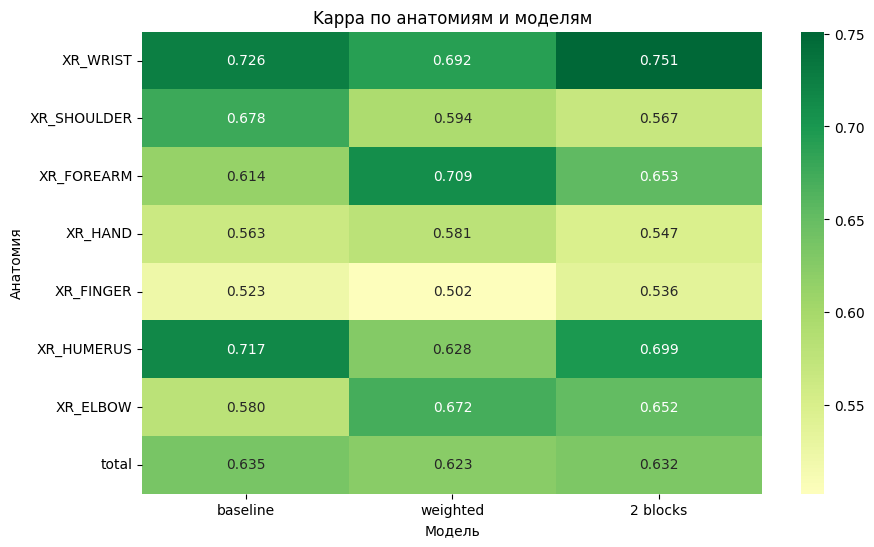

In [91]:
df = pd.DataFrame(kappa_scores)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center = 0.5)

plt.title('Kappa по анатомиям и моделям')
plt.xlabel('Модель')
plt.ylabel('Анатомия')

plt.show()

In [ ]:
torch.save(model.state_dict(), "blocks2_DenseNet.pth")

Тут выросли метрики XR_WRIST, XR_FOREARM, XR_FINGER, XR_ELBOW по сравнению с Бейзлайном

В сравнении с моделью с учетом дисбаланса выигрывают XR_WRIST, XR_FINGER, XR_HUMERUS

На данном этапе лучшие результы:

Baseline - XR_SHOULDER, XR_HUMERUS

Weighted - XR_FOREARM, XR_HAND, XR_ELBOW

2 Blocks - XR_WRIST, XR_FINGER

#### Аугментация с акцентом на проседающие анатомии

In [ ]:
train_transform_normal = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

train_transform_weak = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
    ])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

In [16]:
weak = {'XR_SHOULDER', 'XR_HAND', 'XR_FINGER'}
class MURADataset_augm(Dataset):
    def __init__(self, df, transform_normal=None, transform_weak=None):
        self.df = df
        self.transform_normal = transform_normal
        self.transform_weak = transform_weak

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["path"]).convert("RGB")

        if self.transform_weak and row["anatomy"] in weak:
            img = self.transform_weak(img)
        else:
            img = self.transform_normal(img)

        return (
          img,
          float(row["label"]),
          row["unique_study_id"],   # ← вместо старого
          row["anatomy"]
            )

In [ ]:
train_dataset = MURADataset_augm(train_df, train_transform_normal, train_transform_weak)
val_dataset   = MURADataset_augm(val_df, transform_normal = val_transform, transform_weak = None)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    worker_init_fn=worker_init_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    worker_init_fn=worker_init_fn
)

In [ ]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# 1. freeze everything
for p in model.parameters():
    p.requires_grad = False

# 2. unfreeze 3 + 4
for name, p in model.named_parameters():
    if name.startswith("features.denseblock4") or name.startswith("features.denseblock3"):
        p.requires_grad = True

# 3. classifier
model.classifier = nn.Linear(model.classifier.in_features, 1)

for p in model.classifier.parameters():
    p.requires_grad = True

In [ ]:
model = model.to(device)

optimizer = torch.optim.Adam([
    {'params': filter(lambda p: p.requires_grad, model.features.parameters()), 'lr': 1e-6},
    {'params': model.classifier.parameters(), 'lr': 1e-5},
])

In [ ]:
num_epochs = 20
best_kappa = -1
patience = 5
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_loss = train_one_epoch()

    all_probs, all_labels, all_study_ids, all_anatomy = validate()
    study_df = aggregate(all_probs, all_labels, all_study_ids, all_anatomy)

    metrics = compute_metrics(study_df)
    print(epoch, train_loss, metrics)
    if metrics["kappa"] > best_kappa:
        best_kappa = metrics["kappa"]
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        break


Epoch 1/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

0 0.7172195646742846 {'acc': 0.5737874097007224, 'auc': np.float64(0.6256167956557062), 'kappa': np.float64(0.10665327306211292)}

Epoch 2/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

...

Val:   0%|          | 0/48 [00:00<?, ?it/s]

18 0.5339851348291996 {'acc': 0.782249742002064, 'auc': np.float64(0.8606576303074357), 'kappa': np.float64(0.5556485246528691)}

Epoch 20/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

19 0.5318786860644837 {'acc': 0.7874097007223942, 'auc': np.float64(0.8627528113909437), 'kappa': np.float64(0.5645589832859965)}


In [ ]:
best_t, best_kappa = threshold(study_df)

print("best threshold:", best_t)
print("best kappa:", best_kappa)

best threshold: 0.4120603015075377
best kappa: 0.5817633272475364


In [ ]:
augm_metrics = compute_metrics(study_df, threshold=best_t)
print(augm_metrics)

augm_by_anatomy = {}

for a in study_df["anatomy"].unique():
    part = study_df[study_df["anatomy"] == a]

    if part["label"].nunique() < 2:
        continue

    augm_by_anatomy[a] = compute_metrics(part, threshold=best_t)

{'acc': 0.7936016511867905, 'auc': np.float64(0.8627528113909437), 'kappa': np.float64(0.5817633272475364)}


In [ ]:
pd.DataFrame(augm_by_anatomy).T

,acc,auc,kappa
XR_WRIST,0.820652,0.885946,0.628397
XR_SHOULDER,0.771605,0.869910,0.544183
XR_FOREARM,0.825243,0.899245,0.652549
XR_HAND,0.742424,0.816239,0.417445
XR_FINGER,0.775758,0.832058,0.547677
XR_HUMERUS,0.831858,0.918495,0.663321
XR_ELBOW,0.800000,0.887897,0.596935


In [ ]:
torch.save(model.state_dict(), "augm_DenseNet.pth")

In [106]:
kappa_scores['Augmented'] = {
    k: float(v['kappa']) for k, v in augm_by_anatomy.items()
}

kappa_scores['Augmented']['total'] = float(
    np.mean([v['kappa'] for v in augm_by_anatomy.values()])
    )

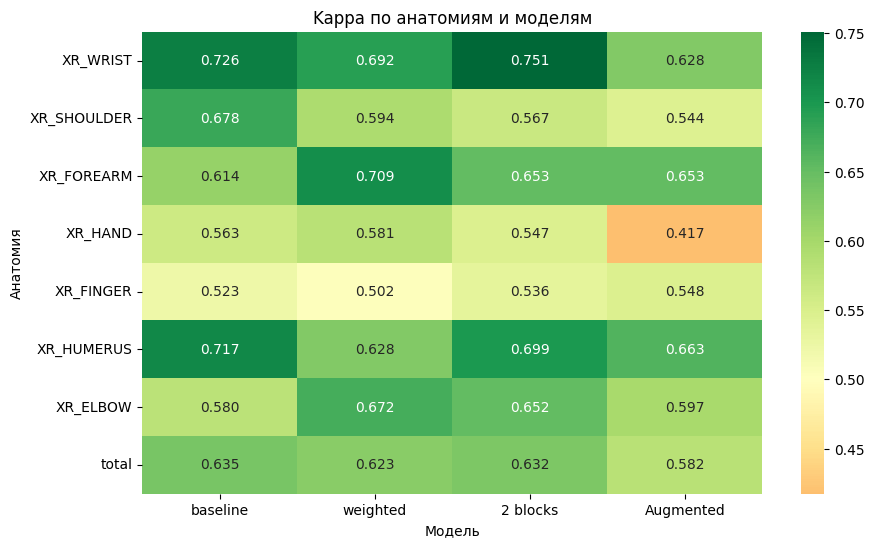

In [107]:
df = pd.DataFrame(kappa_scores)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center = 0.5)

plt.title('Kappa по анатомиям и моделям')
plt.xlabel('Модель')
plt.ylabel('Анатомия')

plt.show()

Аугментация привела хоть к какому-то улучшению только для XR_FINGER

Oversampling

In [23]:
weights = train_df['anatomy'].apply(
    lambda x: 2.0 if x in weak else 1.0
)

sampler = WeightedRandomSampler(
    weights= weights.values,
    num_samples = len(weights),
    replacement = True
)

In [24]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

In [32]:
train_dataset = MURADataset(train_df, train_transform)
val_dataset   = MURADataset(val_df, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler = sampler,
    num_workers=0,
    pin_memory=True,
    worker_init_fn=worker_init_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    worker_init_fn=worker_init_fn
)

In [39]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# 1. freeze everything
for p in model.parameters():
    p.requires_grad = False

# 2. unfreeze 3 + 4
for name, p in model.named_parameters():
    if name.startswith("features.denseblock4") or name.startswith("features.denseblock3"):
        p.requires_grad = True

# 3. classifier
model.classifier = nn.Linear(model.classifier.in_features, 1)

for p in model.classifier.parameters():
    p.requires_grad = True

In [40]:
model = model.to(device)

optimizer = torch.optim.Adam([
    {'params': filter(lambda p: p.requires_grad, model.features.parameters()), 'lr': 1e-6},
    {'params': model.classifier.parameters(), 'lr': 1e-5},
])

In [41]:
num_epochs = 20
best_kappa = -1
patience = 5
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_loss = train_one_epoch()

    all_probs, all_labels, all_study_ids, all_anatomy = validate()
    study_df = aggregate(all_probs, all_labels, all_study_ids, all_anatomy)

    metrics = compute_metrics(study_df)
    print(epoch, train_loss, metrics)
    if metrics["kappa"] > best_kappa:
        best_kappa = metrics["kappa"]
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        break


Epoch 1/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

0 0.6649231382484714 {'acc': 0.5830753353973168, 'auc': np.float64(0.6751272074229273), 'kappa': np.float64(0.12137643752973803)}

Epoch 2/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

...

Val:   0%|          | 0/48 [00:00<?, ?it/s]

18 0.4290234784001666 {'acc': 0.7946336429308566, 'auc': np.float64(0.8696155984093726), 'kappa': np.float64(0.5805970311565439)}

Epoch 20/20


Train:   0%|          | 0/533 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

19 0.4223064059325362 {'acc': 0.7977296181630547, 'auc': np.float64(0.8697695300808141), 'kappa': np.float64(0.5876076449053507)}


In [42]:
best_t, best_kappa = threshold(study_df)

print("best threshold:", best_t)
print("best kappa:", best_kappa)

best threshold: 0.4170854271356784
best kappa: 0.6246384546518835


In [43]:
sampler_metrics = compute_metrics(study_df, threshold=best_t)
print(sampler_metrics)

sampler_by_anatomy = {}

for a in study_df["anatomy"].unique():
    part = study_df[study_df["anatomy"] == a]

    if part["label"].nunique() < 2:
        continue

    sampler_by_anatomy[a] = compute_metrics(part, threshold=best_t)

{'acc': 0.8142414860681114, 'auc': np.float64(0.8697695300808141), 'kappa': np.float64(0.6246384546518835)}


In [44]:
pd.DataFrame(sampler_by_anatomy).T

,acc,auc,kappa
XR_WRIST,0.853261,0.917150,0.695961
XR_SHOULDER,0.820988,0.892634,0.642520
XR_FOREARM,0.834951,0.883774,0.671297
XR_HAND,0.780303,0.823837,0.510736
XR_FINGER,0.775758,0.843686,0.548614
XR_HUMERUS,0.823009,0.893730,0.645435
XR_ELBOW,0.809091,0.852844,0.616661


In [45]:
torch.save(model.state_dict(), "sampler_DenseNet.pth")

In [103]:
kappa_scores['Sampler'] = {
    k: float(v['kappa']) for k, v in sampler_by_anatomy.items()
}

kappa_scores['Sampler']['total'] = float(
    np.mean([v['kappa'] for v in sampler_by_anatomy.values()])
    )

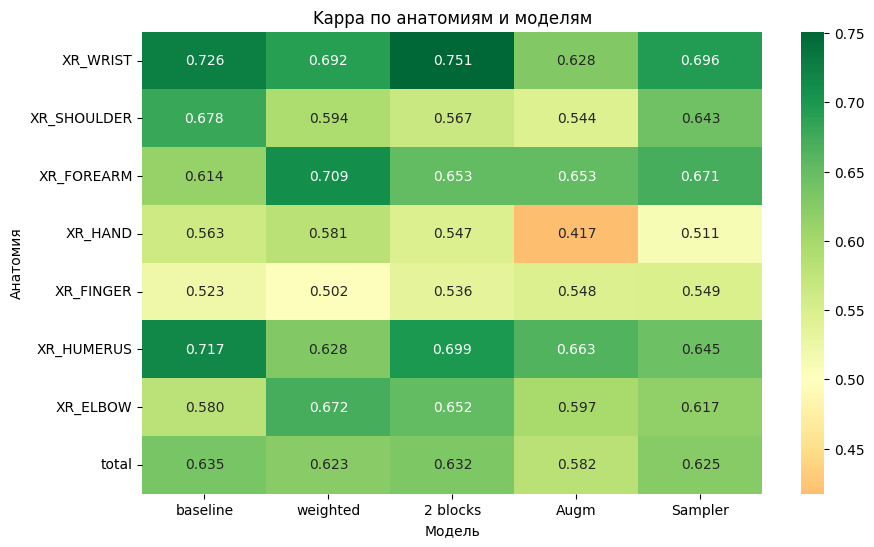

In [99]:
df = pd.DataFrame(kappa_scores)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center = 0.5)

plt.title('Kappa по анатомиям и моделям')
plt.xlabel('Модель')
plt.ylabel('Анатомия')

plt.show()

#### Адаптивный threshhold для каждой анатомии

In [73]:
def best_threshhold(study_df):
  thresholds = {}

  for anatomy in study_df['anatomy'].unique():
    part = study_df[study_df['anatomy'] == anatomy]

    y_true = part['label'].values
    y_prob = part['prob'].values
    best_t = 0
    best_kappa = -1

    for t in np.linspace(0, 1, 200):
      y_pred = (y_prob > t).astype(int)
      k = cohen_kappa_score(y_true, y_pred)

      if k > best_kappa:
        best_kappa = k
        best_t = t
    thresholds[anatomy] = best_t

  return thresholds

In [81]:
def apply_threshholds(study_df, threshholds):
  y_true_all = []
  y_pred_all = []

  for anatomy in study_df['anatomy'].unique():
    part = study_df[study_df['anatomy'] == anatomy]
    if anatomy not in thresholds:
      continue

    t = thresholds[anatomy]
    y_true = part['label'].values
    y_prob = part['prob'].values
    y_pred = (y_prob > t).astype(int)

    y_true_all.extend(y_true)
    y_pred_all.extend(y_pred)

  return np.array(y_true_all), np.array(y_pred_all)

DataLoader и модель

In [74]:
train_dataset = MURADataset(train_df, train_transform)
val_dataset   = MURADataset(val_df, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    worker_init_fn=worker_init_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    worker_init_fn=worker_init_fn
)

In [75]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# 1. freeze everything
for p in model.parameters():
    p.requires_grad = False

# 2. unfreeze 3 + 4
for name, p in model.named_parameters():
    if name.startswith("features.denseblock4") or name.startswith("features.denseblock3"):
        p.requires_grad = True

# 3. classifier
model.classifier = nn.Linear(model.classifier.in_features, 1)

for p in model.classifier.parameters():
    p.requires_grad = True

In [76]:
model = model.to(device)

optimizer = torch.optim.Adam([
    {'params': filter(lambda p: p.requires_grad, model.features.parameters()), 'lr': 1e-6},
    {'params': model.classifier.parameters(), 'lr': 1e-5},
])

Загрузка весов обученной модели

In [77]:
model.load_state_dict(torch.load('blocks2_DenseNet.pth', map_location=device))
model.eval()

all_probs, all_labels, all_study_ids, all_anatomy = validate()
study_df = aggregate(all_probs, all_labels, all_study_ids, all_anatomy)

Val:   0%|          | 0/48 [00:00<?, ?it/s]

Подсчет трешхолдов и применение для вычисления метрик

In [78]:
thresholds = best_threshhold(study_df)

In [82]:
y_true, y_pred = apply_threshholds(study_df, thresholds)

kappa_total = cohen_kappa_score(y_true, y_pred)
print('kappa total:', kappa_total)

kappa total: 0.6621746091866951


In [83]:
thr_by_anatomy = {}
for a in study_df["anatomy"].unique():
    part = study_df[study_df["anatomy"] == a]
    if len(part) < 2:
      continue
    y_true = part['label'].values
    y_prob = part['prob'].values

    if len(np.unique(y_true)) < 2:
      continue

    t = thresholds.get(a, 0.5)
    y_pred = (y_prob > t).astype(int)

    thr_by_anatomy[a] = compute_metrics(part, threshold=t)

In [84]:
pd.DataFrame(thr_by_anatomy).T

,acc,auc,kappa
XR_WRIST,0.880435,0.922230,0.750984
XR_SHOULDER,0.808642,0.877840,0.618563
XR_FOREARM,0.864078,0.900755,0.727925
XR_HAND,0.810606,0.844492,0.588323
XR_FINGER,0.787879,0.826906,0.570344
XR_HUMERUS,0.858407,0.909404,0.716881
XR_ELBOW,0.827273,0.880291,0.652709


In [104]:
kappa_scores['adaptive_threshold'] = {
    k: float(v['kappa']) for k, v in thr_by_anatomy.items()
}

kappa_scores['adaptive_threshold']['total'] = float(
    np.mean([v['kappa'] for v in thr_by_anatomy.values()])
    )

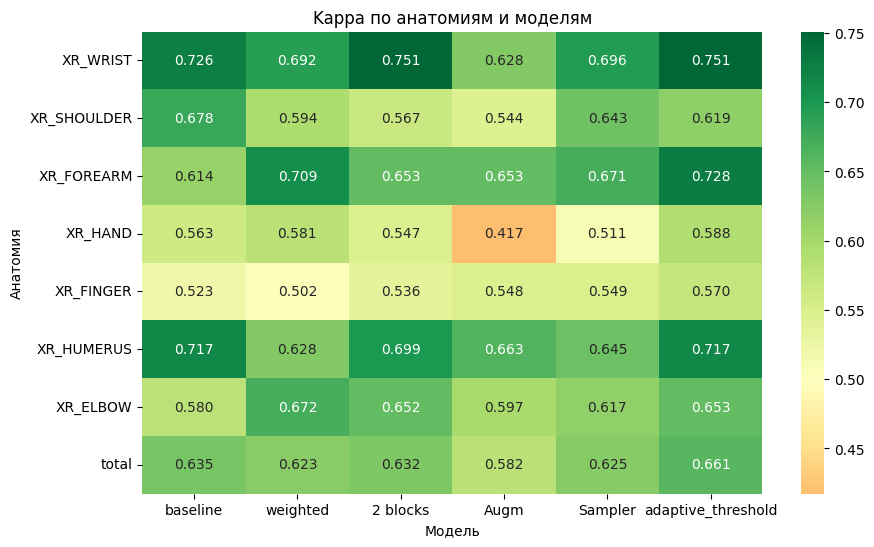

In [105]:
df = pd.DataFrame(kappa_scores)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center = 0.5)

plt.title('Kappa по анатомиям и моделям')
plt.xlabel('Модель')
plt.ylabel('Анатомия')

plt.show()